# Unsupervised Learning – PR 1
## Mall Customer Segmentation


## Import Libraries

**Objective:** Import all libraries required for data analysis, visualisation, preprocessing, and clustering.

**Expected:** All required libraries are imported without errors.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


# Task 1: Data Loading & Exploratory Data Analysis (EDA)

**Objective:** Load the Mall Customers dataset and understand its structure, distributions, relationships, and basic data quality.

**Expected Output:** Dataset information, summary statistics, distributions, pairplot, correlation heatmap, and EDA observations.

## 1.1 Load the Dataset

Load `Mall_Customers.csv` using pandas and inspect the first few records.

**Expected:** 200 rows and 5 columns.

In [2]:
df = pd.read_csv('Mall_Customers.csv')

print("Dataset Shape:", df.shape)
display(df.head())

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe())


Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Summary Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 1.2 Check Missing Values and Duplicates

**Objective:** Confirm that the dataset has no missing values and no duplicate records.

**Expected:** Zero null values and zero duplicate rows.

In [3]:
print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())


Missing values:


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


## 1.3 Rename and Drop Columns

`CustomerID` is only an identifier, so it is dropped before modelling.  
The two columns with spaces and special characters are renamed for cleaner Python code.

**Expected:** Four columns: `Gender`, `Age`, `Annual_Income`, `Spending_Score`.

In [4]:
df = df.rename(columns={
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
})

df = df.drop(columns=['CustomerID'])

print("Columns after preprocessing:")
print(df.columns.tolist())

display(df.head())


Columns after preprocessing:
['Gender', 'Age', 'Annual_Income', 'Spending_Score']


,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


## 1.4 Encode Gender

**Objective:** Convert the text values in `Gender` into binary numeric values using `LabelEncoder`.

**Expected:** Gender becomes numeric 0/1.

In [5]:
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])

print("Gender encoding:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

display(df.head())


Gender encoding:
{'Female': np.int64(0), 'Male': np.int64(1)}


,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


## 1.5 Univariate Distributions

**Objective:** Understand the individual distributions of Age, Annual Income, and Spending Score.

**Expected:** Three histograms with KDE curves.

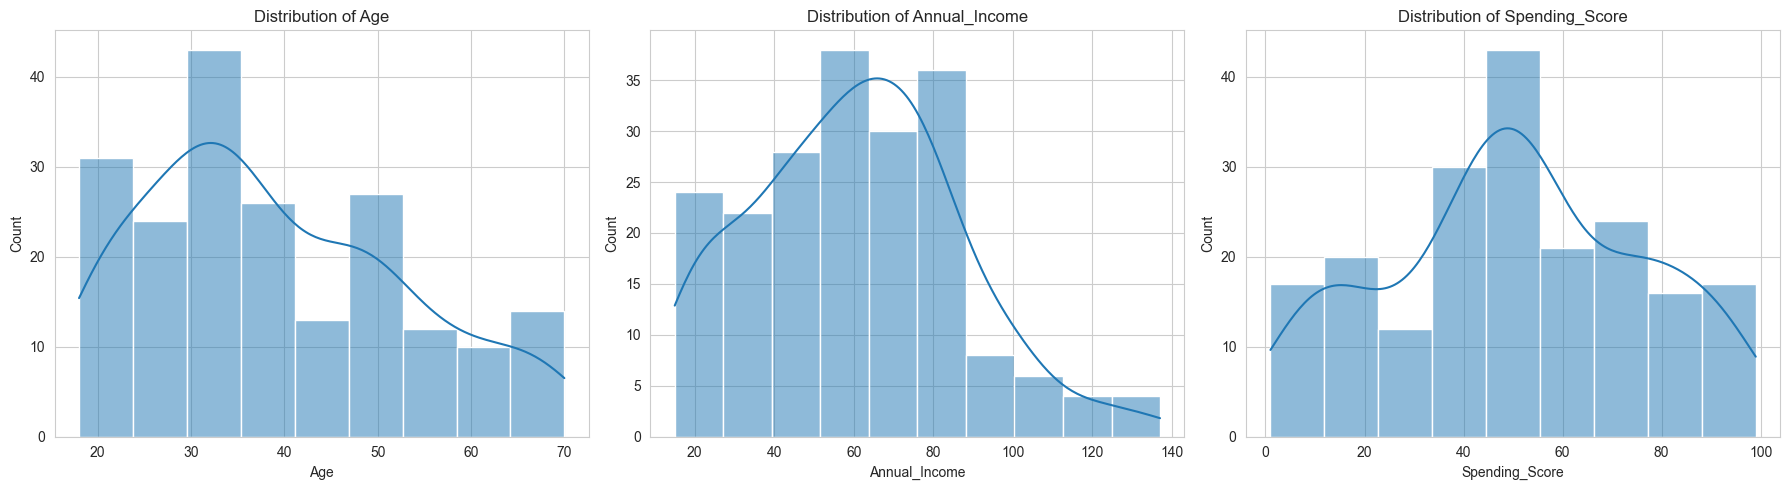

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ['Age', 'Annual_Income', 'Spending_Score']

for ax, feature in zip(axes, features):
    sns.histplot(df[feature], kde=True, ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()


## 1.6 Pairplot

**Objective:** Check relationships between the numerical features and look for visible customer groupings.

**Expected:** Pairplot showing relationships among the variables.

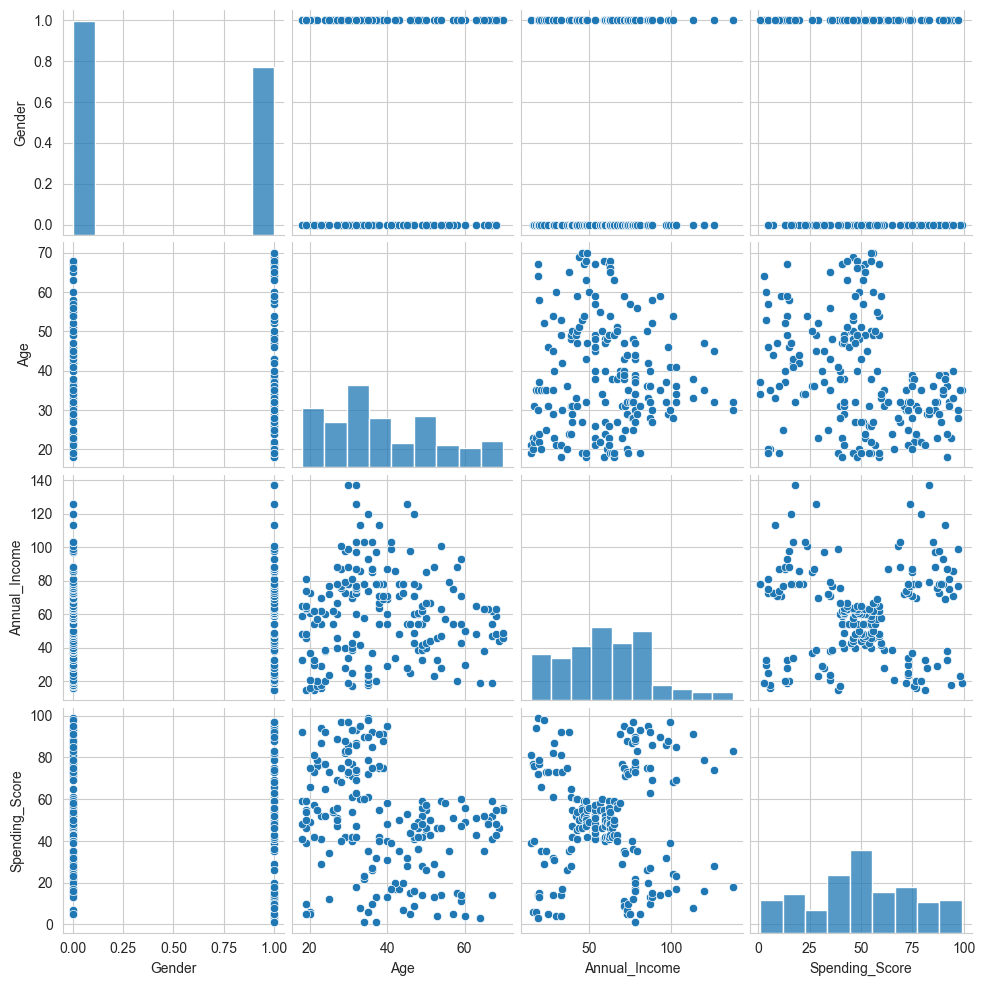

In [7]:
sns.pairplot(df)
plt.show()


## 1.7 Correlation Heatmap

**Objective:** Identify the strength and direction of relationships between numerical features.

**Expected:** Annotated correlation heatmap.

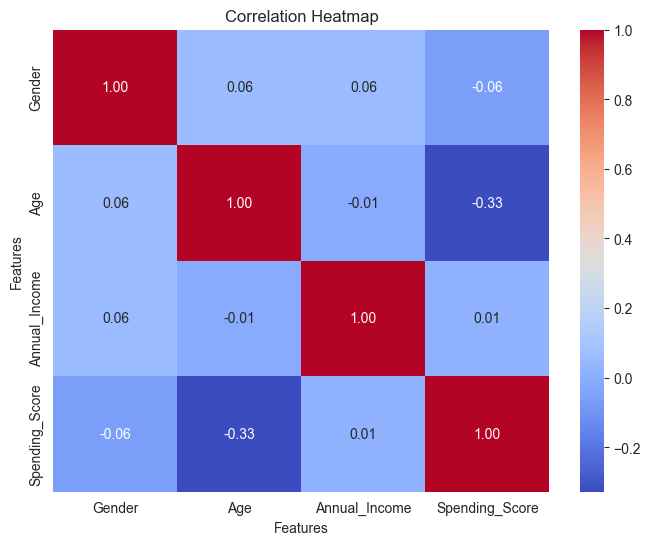

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()


## 1.8 EDA Summary

- The dataset contains 200 customer records and 5 original columns.
- CustomerID is an identifier and is not useful for clustering, so it is removed.
- Age, Annual Income, and Spending Score show different distributions.
- Annual Income and Spending Score are useful for visually separating customer groups.
- Annual Income vs Spending Score is the classic customer-segmentation view because it can reveal customers with different income and spending behaviour.

# Task 2: Feature Scaling & Feature Selection

**Objective:** Standardize the numeric features and create the two-feature dataset used for the primary clustering tasks.

**Expected Output:** `df_scaled` and `df_2f`.

## 2.1 Scale Features

StandardScaler is applied to Age, Annual Income, and Spending Score.

Gender is not scaled because it is already a binary encoded feature.

**Why scaling?** Distance-based algorithms such as K-Means and DBSCAN are sensitive to feature magnitude. Without scaling, a feature with a larger numerical range can dominate distance calculations.

In [9]:
scaler = StandardScaler()

scaled_values = scaler.fit_transform(
    df[['Age', 'Annual_Income', 'Spending_Score']]
)

df_scaled = pd.DataFrame(
    scaled_values,
    columns=['Age', 'Annual_Income', 'Spending_Score'],
    index=df.index
)

display(df_scaled.head())


,Age,Annual_Income,Spending_Score
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## 2.2 Select Two Features

For the primary clustering tasks, use:

- Annual_Income
- Spending_Score

This makes the clusters easy to visualise in 2D without PCA.

In [10]:
df_2f = df_scaled[['Annual_Income', 'Spending_Score']].copy()

print("df_2f shape:", df_2f.shape)
display(df_2f.head())


df_2f shape: (200, 2)


,Annual_Income,Spending_Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


# Task 3: K-Means Clustering

**Objective:** Find customer groups using K-Means and select a suitable number of clusters using the Elbow Method and Silhouette Score.

**Expected Output:** Elbow plot, Silhouette plot, final K-Means clusters, scatter plot with centroids, and cluster profile table.

## 3.1 Elbow Method

**Objective:** Test K-Means for k = 1 to 10 and inspect inertia.

Inertia is the sum of squared distances between observations and their nearest cluster centroid. The elbow is the point where adding more clusters gives smaller improvement.

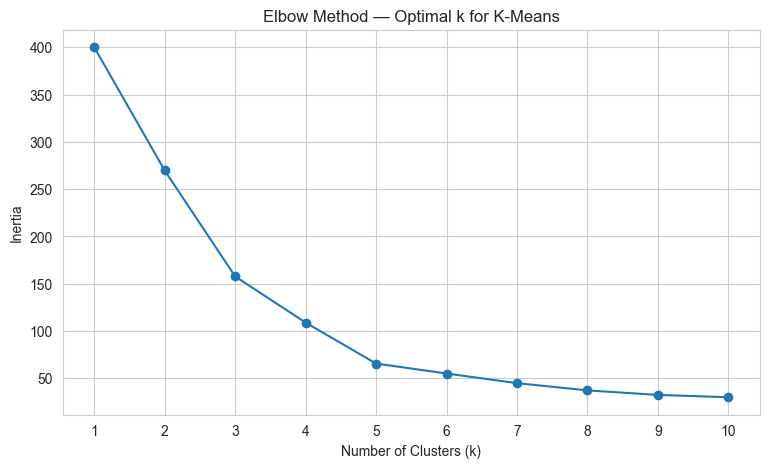

In [11]:
inertias = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(df_2f)
    inertias.append(model.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), inertias, marker='o')
plt.title('Elbow Method — Optimal k for K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))
plt.show()


## 3.2 Silhouette Score

**Objective:** Calculate the silhouette score for k = 2 to 10.

A higher silhouette score generally indicates that observations are well separated from other clusters and close to their own cluster.

,k,Silhouette_Score
0,2,0.321271
1,3,0.466585
2,4,0.493907
3,5,0.554657
4,6,0.539880
5,7,0.528149
6,8,0.455215
7,9,0.457085
8,10,0.443171


Best k based on Silhouette Score: 5


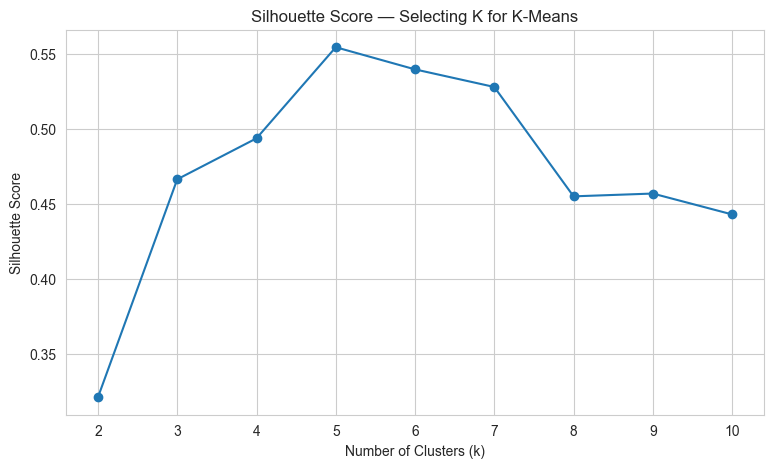

In [12]:
silhouette_scores = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(df_2f)
    score = silhouette_score(df_2f, labels)
    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    'k': range(2, 11),
    'Silhouette_Score': silhouette_scores
})

display(silhouette_results)

best_k = int(
    silhouette_results.loc[
        silhouette_results['Silhouette_Score'].idxmax(), 'k'
    ]
)

print("Best k based on Silhouette Score:", best_k)

plt.figure(figsize=(9, 5))
plt.plot(silhouette_results['k'], silhouette_results['Silhouette_Score'], marker='o')
plt.title('Silhouette Score — Selecting K for K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.show()


## 3.3 Fit Final K-Means Model

Use the data-driven `best_k` selected from the Silhouette Score.

**Expected:** A new `KMeans_Cluster` column.

In [13]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df['KMeans_Cluster'] = kmeans.fit_predict(df_2f)

print("K-Means cluster counts:")
display(df['KMeans_Cluster'].value_counts().sort_index())


K-Means cluster counts:


KMeans_Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

## 3.4 Visualise K-Means Clusters

**Expected:** Annual Income vs Spending Score scatter plot with cluster centroids marked as black X.

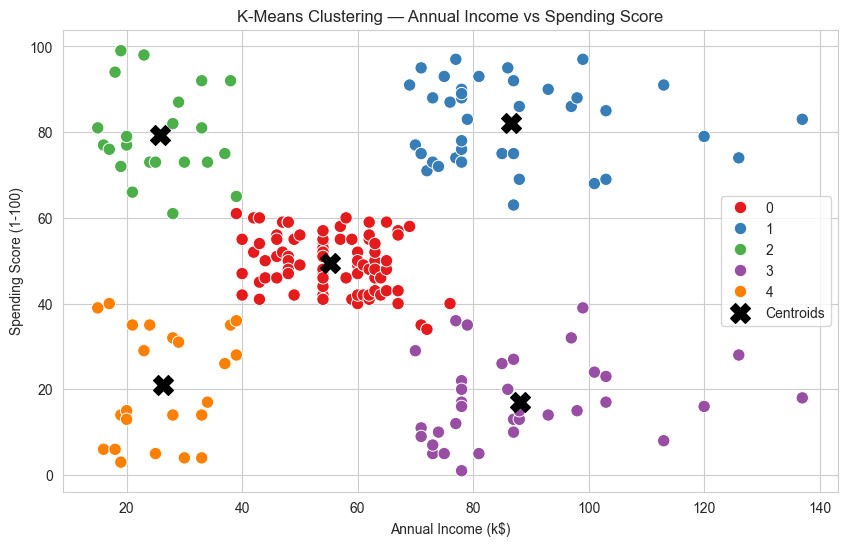

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['KMeans_Cluster'],
    palette='Set1',
    s=80
)

# Convert scaled centroids back to original units for the plot
centers_original = scaler.inverse_transform(
    np.column_stack([
        np.zeros(len(kmeans.cluster_centers_)),
        kmeans.cluster_centers_
    ])
)[:, 1:]

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    c='black',
    marker='X',
    s=200,
    label='Centroids'
)

plt.title('K-Means Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


## 3.5 K-Means Cluster Profile

**Objective:** Calculate the average Age, Annual Income, and Spending Score for each customer segment.

In [15]:
kmeans_profile = df.groupby('KMeans_Cluster')[
    ['Age', 'Annual_Income', 'Spending_Score']
].mean().round(2)

display(kmeans_profile.style.format('{:.2f}'))


,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


### K-Means Business Segment Interpretation

Use the profile table above to describe each cluster. Common segment names include:

- Low Income, Low Spenders
- Low Income, High Spenders
- High Income, Low Spenders
- High Income, High Spenders
- Middle Income / Middle Spenders

The exact interpretation should be based on the actual mean values in the generated profile table.

# Task 4: Agglomerative Hierarchical Clustering

**Objective:** Use hierarchical clustering to build a customer hierarchy and compare its segments with K-Means.

**Expected Output:** Dendrogram, hierarchical clusters, scatter plot, K-Means comparison, and cluster profiles.

## 4.1 Dendrogram

Ward linkage combines observations while minimising the increase in within-cluster variance.

**Expected:** Dendrogram showing how customers merge into larger groups.

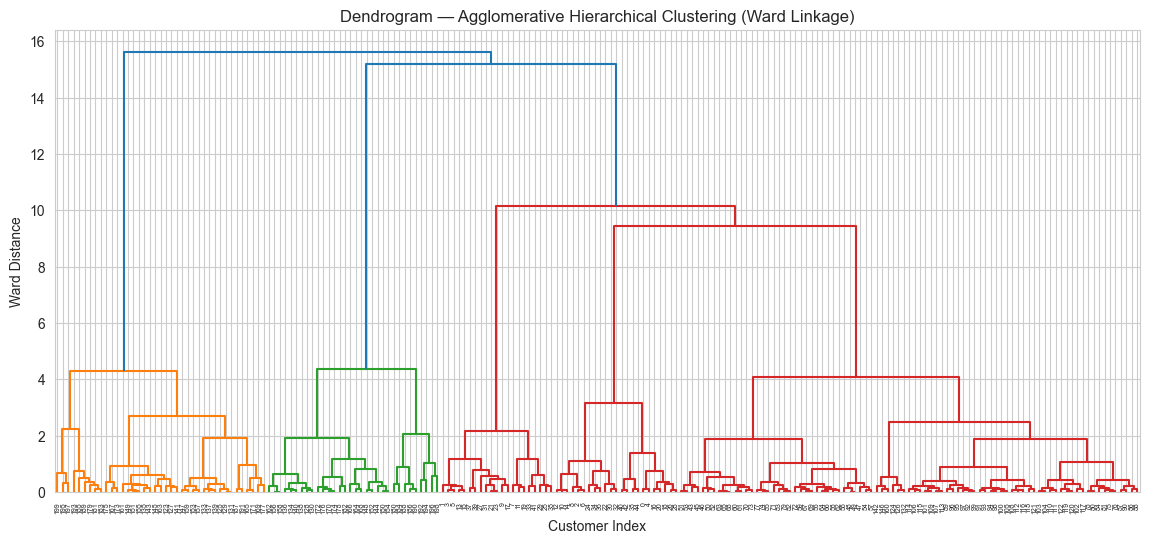

In [16]:
linkage_matrix = linkage(df_2f, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.title('Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)')
plt.xlabel('Customer Index')
plt.ylabel('Ward Distance')
plt.show()


## 4.2 Fit Agglomerative Model

Use the same number of clusters selected for the primary K-Means analysis so the two approaches can be compared directly.

In [17]:
hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage='ward'
)

df['Hier_Cluster'] = hierarchical.fit_predict(df_2f)

print("Hierarchical cluster counts:")
display(df['Hier_Cluster'].value_counts().sort_index())


Hierarchical cluster counts:


Hier_Cluster
0    32
1    39
2    85
3    21
4    23
Name: count, dtype: int64

## 4.3 Visualise Hierarchical Clusters

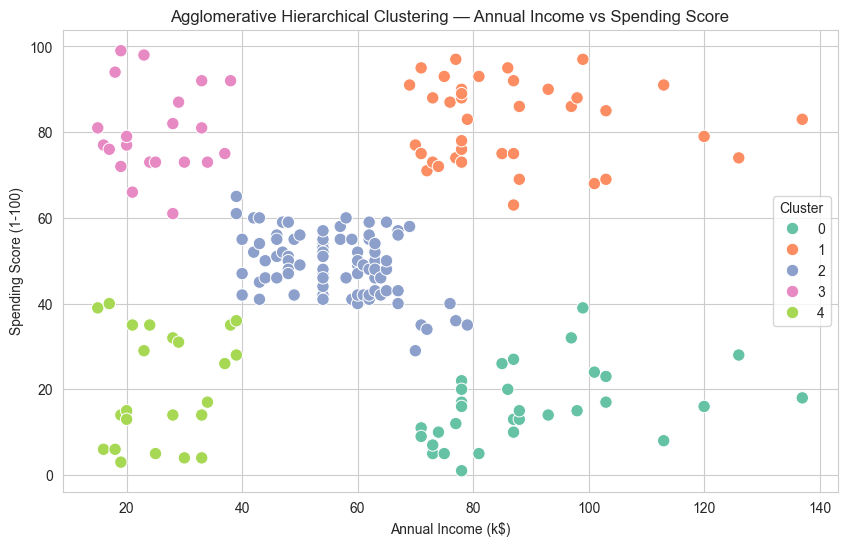

In [18]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['Hier_Cluster'],
    palette='Set2',
    s=80
)

plt.title('Agglomerative Hierarchical Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()


## 4.4 K-Means vs Hierarchical

**Objective:** Compare the two clustering approaches on the same features.

K-Means is centroid-based, while hierarchical clustering is based on progressively merging observations/clusters according to linkage distance.

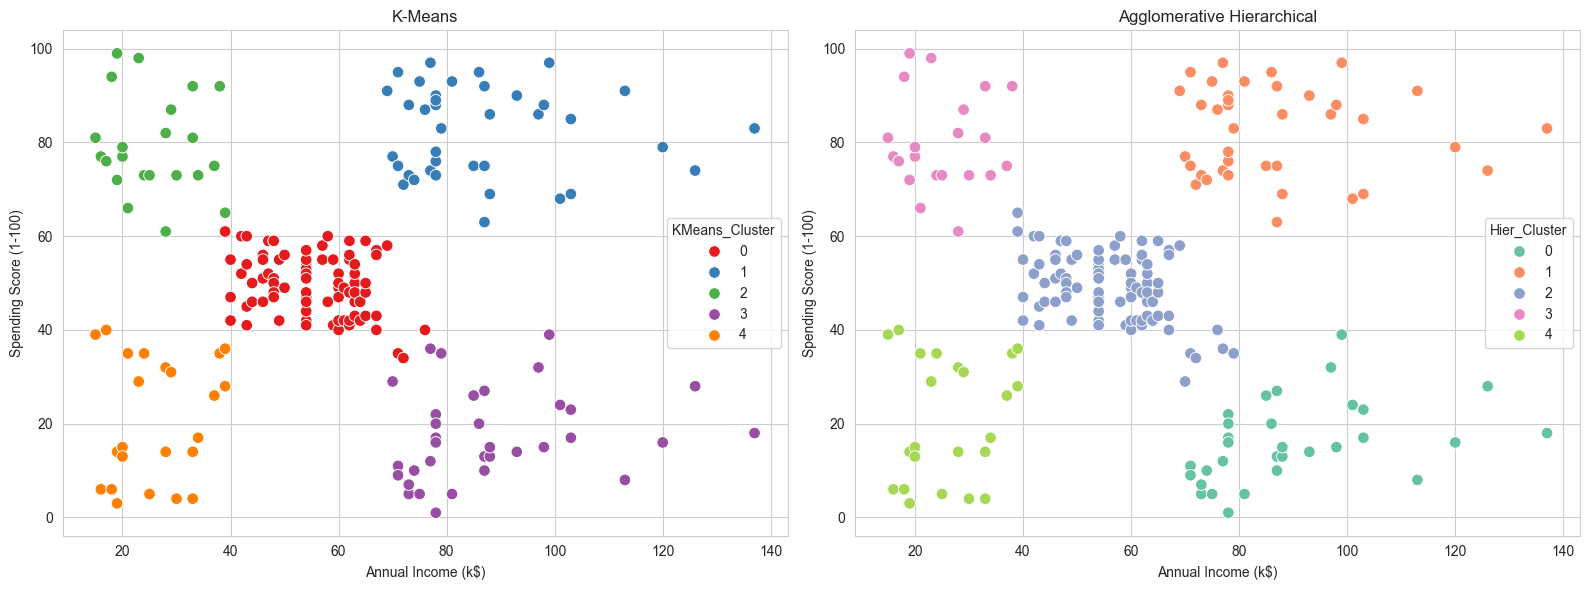

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['KMeans_Cluster'],
    palette='Set1',
    s=70,
    ax=axes[0]
)
axes[0].set_title('K-Means')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')

sns.scatterplot(
    x=df['Annual_Income'],
    y=df['Spending_Score'],
    hue=df['Hier_Cluster'],
    palette='Set2',
    s=70,
    ax=axes[1]
)
axes[1].set_title('Agglomerative Hierarchical')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()


### Comparison Observation

Compare the two scatter plots. If the broad groups look similar, the main customer segments are stable between the two algorithms. Border-region customers may receive different labels because K-Means uses centroids while hierarchical clustering uses connectivity/linkage structure.

## 4.5 Hierarchical Cluster Profile

In [20]:
hier_profile = df.groupby('Hier_Cluster')[
    ['Age', 'Annual_Income', 'Spending_Score']
].mean().round(2)

display(hier_profile.style.format('{:.2f}'))


,Age,Annual_Income,Spending_Score
Hier_Cluster,,,
0,41.00,89.41,15.59
1,32.69,86.54,82.13
2,42.48,55.81,49.13
3,25.33,25.10,80.05
4,45.22,26.30,20.91


# Task 5: DBSCAN Clustering

**Objective:** Use density-based clustering to identify customer groups and possible noise points.

**Expected Output:** 4-NN distance plot, parameter grid-search table, DBSCAN clusters, noise points, and conceptual comparison.

## 5.1 4-NN Distance Plot

The 4th-nearest-neighbour distance can help estimate a suitable `eps` value. A visible knee in the sorted distance curve can be used as a starting point.

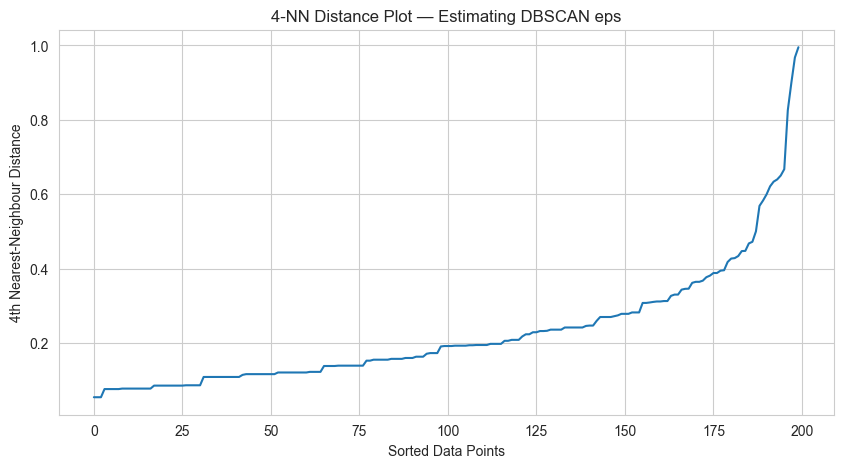

In [21]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(df_2f)

distances, indices = neighbors_fit.kneighbors(df_2f)
k_distances = np.sort(distances[:, 3])

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.title('4-NN Distance Plot — Estimating DBSCAN eps')
plt.xlabel('Sorted Data Points')
plt.ylabel('4th Nearest-Neighbour Distance')
plt.show()


## 5.2 DBSCAN Grid Search

Test:

- `eps`: 0.2, 0.3, 0.4, 0.5, 0.6
- `min_samples`: 3, 4, 5, 6

For each combination, record number of clusters, noise points, and silhouette score. Noise points are excluded from the silhouette calculation.

In [22]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 4, 5, 6]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(df_2f)

        mask = labels != -1
        n_clusters = len(set(labels[mask]))

        if n_clusters >= 2 and mask.sum() > n_clusters:
            score = silhouette_score(df_2f[mask], labels[mask])
        else:
            score = np.nan

        noise_points = int((labels == -1).sum())

        dbscan_results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'noise_points': noise_points,
            'Silhouette_Score': score
        })

dbscan_results = pd.DataFrame(dbscan_results)
display(dbscan_results)


,eps,min_samples,n_clusters,noise_points,Silhouette_Score
0,0.2,3,13,44,0.469713
1,0.2,4,5,73,0.617282
2,0.2,5,7,77,0.585613
3,0.2,6,4,95,0.613836
4,0.3,3,9,14,0.472040
5,0.3,4,8,23,0.519746
6,0.3,5,7,35,0.524328
7,0.3,6,6,48,0.530244
8,0.4,3,4,10,0.395381
9,0.4,4,3,14,0.457570


### Select DBSCAN Parameters

The selection below prioritises a valid silhouette score, then higher silhouette score, while also considering the number of noise points. Review the table and the 4-NN plot before final submission.

In [23]:
valid_results = dbscan_results.dropna(subset=['Silhouette_Score']).copy()

if len(valid_results) > 0:
    # Prefer good separation with lower noise.
    valid_results['noise_ratio'] = valid_results['noise_points'] / len(df_2f)
    valid_results = valid_results.sort_values(
        ['Silhouette_Score', 'noise_points'],
        ascending=[False, True]
    )
    best_dbscan = valid_results.iloc[0]
    best_eps = float(best_dbscan['eps'])
    best_min_samples = int(best_dbscan['min_samples'])
else:
    # Fallback only if no tested combination has >= 2 clusters.
    best_eps = 0.5
    best_min_samples = 5

print("Selected DBSCAN eps:", best_eps)
print("Selected DBSCAN min_samples:", best_min_samples)


Selected DBSCAN eps: 0.2
Selected DBSCAN min_samples: 4


## 5.3 Fit Final DBSCAN Model

In [24]:
dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

df['DBSCAN_Cluster'] = dbscan.fit_predict(df_2f)

print("DBSCAN cluster counts:")
display(df['DBSCAN_Cluster'].value_counts().sort_index())


DBSCAN cluster counts:


DBSCAN_Cluster
-1    73
 0     7
 1    79
 2    21
 3    14
 4     6
Name: count, dtype: int64

## 5.4 Visualise DBSCAN

Noise points have label `-1`. They are shown separately using black `x` markers.

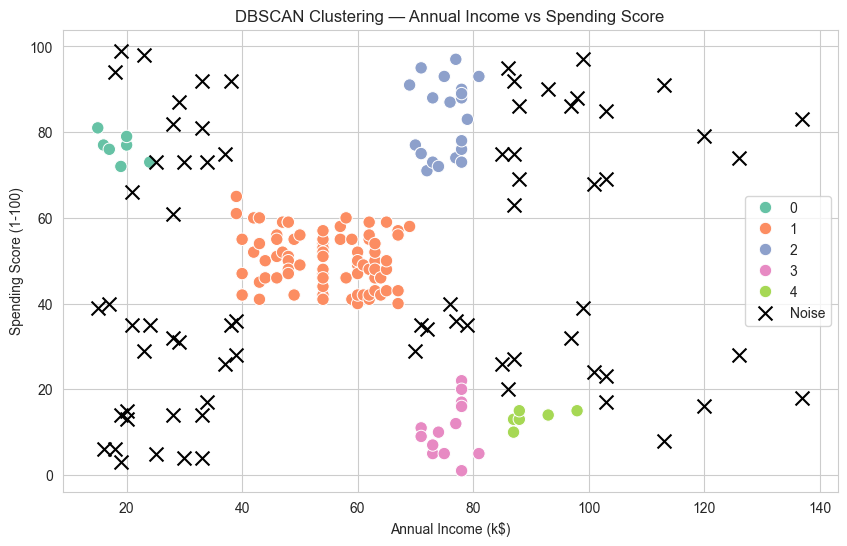

In [25]:
plt.figure(figsize=(10, 6))

non_noise = df[df['DBSCAN_Cluster'] != -1]
noise = df[df['DBSCAN_Cluster'] == -1]

sns.scatterplot(
    data=non_noise,
    x='Annual_Income',
    y='Spending_Score',
    hue='DBSCAN_Cluster',
    palette='Set2',
    s=80
)

if len(noise) > 0:
    plt.scatter(
        noise['Annual_Income'],
        noise['Spending_Score'],
        c='black',
        marker='x',
        s=100,
        label='Noise'
    )

plt.title('DBSCAN Clustering — Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()


## 5.5 DBSCAN vs K-Means

1. DBSCAN does not require the number of clusters `k` in advance.
2. DBSCAN can detect clusters based on density and can handle non-spherical shapes.
3. K-Means assigns every observation to a cluster.
4. DBSCAN can label low-density observations as noise (`-1`).
5. K-Means is often easier to interpret for straightforward customer segmentation, while DBSCAN is useful when density and unusual observations are important.

# Task 6: Algorithm Comparison & Business Insights

**Objective:** Compare K-Means, Hierarchical, and DBSCAN results using visualisations and clustering metrics, then translate the segments into business insights.

**Expected Output:** Three-panel comparison, metrics table, segment descriptions, and marketing actions.

## 6.1 Three-Panel Comparison

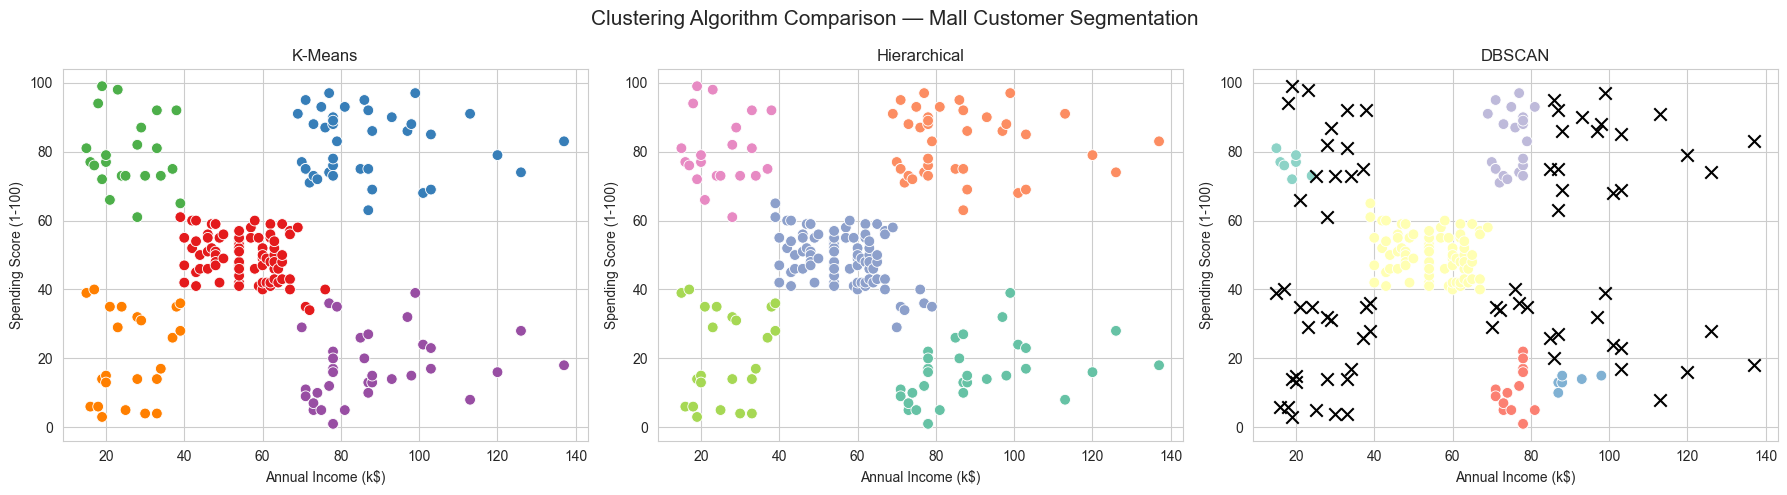

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='KMeans_Cluster',
    palette='Set1',
    s=60,
    ax=axes[0],
    legend=False
)
axes[0].set_title('K-Means')

sns.scatterplot(
    data=df,
    x='Annual_Income',
    y='Spending_Score',
    hue='Hier_Cluster',
    palette='Set2',
    s=60,
    ax=axes[1],
    legend=False
)
axes[1].set_title('Hierarchical')

non_noise = df[df['DBSCAN_Cluster'] != -1]
noise = df[df['DBSCAN_Cluster'] == -1]

sns.scatterplot(
    data=non_noise,
    x='Annual_Income',
    y='Spending_Score',
    hue='DBSCAN_Cluster',
    palette='Set3',
    s=60,
    ax=axes[2],
    legend=False
)

if len(noise) > 0:
    axes[2].scatter(
        noise['Annual_Income'],
        noise['Spending_Score'],
        c='black',
        marker='x',
        s=80
    )

axes[2].set_title('DBSCAN')

for ax in axes:
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')

fig.suptitle(
    'Clustering Algorithm Comparison — Mall Customer Segmentation',
    fontsize=15
)
plt.tight_layout()
plt.show()


## 6.2 Metrics Summary

For DBSCAN, noise points are excluded from the metric calculations.

- **Silhouette Score:** higher generally indicates better separation.
- **Davies-Bouldin Index:** lower generally indicates better separation.
- **Calinski-Harabasz Index:** higher generally indicates better-defined clusters.

These metrics should be considered together with visual separation and business interpretability.

In [27]:
def calculate_metrics(labels, X, algorithm_name):
    mask = labels != -1 if algorithm_name == 'DBSCAN' else np.ones(len(labels), dtype=bool)
    filtered_labels = labels[mask]
    filtered_X = X[mask]

    n_clusters = len(set(filtered_labels))

    if n_clusters >= 2 and len(filtered_labels) > n_clusters:
        sil = silhouette_score(filtered_X, filtered_labels)
        dbi = davies_bouldin_score(filtered_X, filtered_labels)
        ch = calinski_harabasz_score(filtered_X, filtered_labels)
    else:
        sil = np.nan
        dbi = np.nan
        ch = np.nan

    return {
        'Algorithm': algorithm_name,
        'n_clusters': n_clusters,
        'Silhouette Score': sil,
        'Davies-Bouldin Index': dbi,
        'Calinski-Harabasz Index': ch
    }

metrics_summary = pd.DataFrame([
    calculate_metrics(
        df['KMeans_Cluster'].values,
        df_2f.values,
        'K-Means'
    ),
    calculate_metrics(
        df['Hier_Cluster'].values,
        df_2f.values,
        'Hierarchical'
    ),
    calculate_metrics(
        df['DBSCAN_Cluster'].values,
        df_2f.values,
        'DBSCAN'
    )
])

display(metrics_summary.round(4))


,Algorithm,n_clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,5,0.5547,0.5722,248.6493
1,Hierarchical,5,0.5538,0.5779,244.4103
2,DBSCAN,5,0.6173,0.5403,229.5224


## 6.3 Business Insights for Mall Management

### K-Means Customer Segments

Use the K-Means profile table from Task 3.5 to describe the actual segments. A useful interpretation is:

- **High Income + High Spending:** valuable customers; suitable for loyalty rewards and premium offers.
- **High Income + Low Spending:** customers with purchasing potential; suitable for personalised offers.
- **Low Income + High Spending:** price-sensitive but active customers; suitable for targeted discounts and budget promotions.
- **Low Income + Low Spending:** lower current spending; suitable for basic promotions and awareness campaigns.
- **Middle Income / Middle Spending:** regular customers; suitable for general loyalty and seasonal campaigns.

### Business Note

The final segment names should be matched to the actual mean values in the generated K-Means profile table rather than assumed blindly.

## 6.4 Algorithm Interpretation

- **K-Means:** easy to understand and useful when the required customer segments are reasonably compact and centroid-based.
- **Hierarchical:** useful when management wants to see the hierarchy of how customers/groups merge.
- **DBSCAN:** useful when density-based grouping and noise/outlier identification are important.

For a deployment decision, consider the metric results, visual structure, stability, business meaning, and ease of explaining the segments to stakeholders.